In [1]:
import h5py
import numpy as np
from illustris_python.groupcat import loadSingle, loadHeader
import illustris_python as il
import matplotlib.pyplot as plt
import matplotlib 
import mpl_toolkits.mplot3d as mpl3
from matplotlib.gridspec import GridSpec
import requests
import pandas as pd
from tqdm import tqdm
import warnings
warnings.filterwarnings('ignore')
import tempfile
import contextlib
import os
from datetime import datetime
import time


In [2]:
# Constante de Hubble en unidades de [km/s / Mpc]:
H0 = 67.74
h = H0 / 100 

# Tamaño del box de simulación
box_size = 204.98124  # Mpc/h

# Path de las simulaciones TNG300-1 en este directorio:
myBasePath = '../sims.TNG/TNG300-1/output' 

# PASO 1: BAJAR HALOS QUE A Z=0 TENGAN $M_{200}$ EN [Msun/h] MAYOR A 13.5

In [3]:
# Traemos algunas propiedades de TODOS los halos de las TNG300
data_halos = il.groupcat.loadHalos(myBasePath, 99, fields=['GroupFirstSub', 'Group_M_Crit200', 'Group_R_Crit200', 'GroupPos', 'GroupVel'])

In [4]:
# Armamos un DataFrame con la info bajada en las unidades correctas
halos = pd.DataFrame({
    'id_z0': np.arange(len(data_halos['GroupPos'])),
    'id_central_galaxy_z0': data_halos['GroupFirstSub'],
    'm200_z0': np.log10(data_halos['Group_M_Crit200'] * 1e10), # Msun/h
    'r200_z0': data_halos['Group_R_Crit200'] / 1000, # cMpc/h
    'pos_x_z0': data_halos['GroupPos'][:, 0] / 1000, # cMpc/h
    'pos_y_z0': data_halos['GroupPos'][:, 1] / 1000, # cMpc/h
    'pos_z_z0': data_halos['GroupPos'][:, 2] / 1000, # cMpc/h
    'vel_x_z0': data_halos['GroupVel'][:, 0], # km/s
    'vel_y_z0': data_halos['GroupVel'][:, 1], # km/s
    'vel_z_z0': data_halos['GroupVel'][:, 2] # km/s
})

# Seleccionamos el treshold en M_200
halos = halos[halos['m200_z0'] >= 13.5]
len(halos)

754

# PASO 2: CRITERIO DE AISLAMIENTO

In [5]:
def periodic_distance(pos1, pos2, box_size):
    """
    Calcula la distancia periódica entre dos posiciones.
    
    Parameters:
    -----------
    pos1 : array (3,)
        Posición del primer objeto [x, y, z]
    pos2 : array (N, 3) 
        Posiciones de N objetos
    box_size : float
        Tamaño de la caja de simulación
        
    Returns:
    --------
    distances : array (N,)
        Distancias periódicas
    """
    # Diferencia en cada dimensión
    delta = np.abs(pos2 - pos1)
    
    # Aplicar condición de periodicidad: si delta > box_size/2, usar camino corto
    delta = np.minimum(delta, box_size - delta)
    
    # Distancia euclidiana 3D
    distances = np.sqrt(np.sum(delta**2, axis=1))
    
    return distances

In [6]:
def filter_isolated_halos(halos_df, data_halos, box_size, verbose=True):
    '''
    Filtra halos que cumplen el criterio de aislamiento simple:
    Descarta un halo si tiene otro halo con masa > 10% de su m200 dentro de 5*r200
    
    INCLUYE CORRECCIÓN DE PERIODICIDAD para condiciones de frontera.
    
    Parameters:
    -----------
    halos_df : DataFrame
        DataFrame con los halos seleccionados
    data_halos : dict
        Diccionario con todos los halos de la simulación
    box_size : float
        Tamaño de la caja de simulación (Mpc/h)
    verbose : bool
        Si imprimir información del progreso
        
    Returns:
    --------
    DataFrame con halos aislados
    '''
    
    # Convertir masas de data_halos a log10(M_sun) como en tu DataFrame
    all_masses_log = np.log10(data_halos['Group_M_Crit200'] * 1e10) # Msun/h
    all_positions_mpc = data_halos['GroupPos'] / 1000  # Mpc/h
    
    # Filtrar halos válidos (masa > 0)
    valid_mask = data_halos['Group_M_Crit200'] > 0
    all_masses_log = all_masses_log[valid_mask]
    all_positions_mpc = all_positions_mpc[valid_mask]
    
    if verbose:
        print(f'Total de halos válidos en data_halos: {len(all_masses_log)}')
        print(f'Halos a verificar: {len(halos_df)}')
    
    isolated_indices = []
    
    for idx, halo in halos_df.iterrows():
        halo_id = halo['id_z0'] # ID del halo actual
        halo_mass = halo['m200_z0'] # log10(Msun/h)
        halo_radius = halo['r200_z0'] # Mpc/h
        halo_pos = np.array([halo['pos_x_z0'], halo['pos_y_z0'], halo['pos_z_z0']]) # Mpc/h
        
        # Masa mínima para considerar (10% de la masa del halo)
        min_mass_log = halo_mass + np.log10(0.1) # log10(0.1 * M_halo)
        
        # Radio de búsqueda      
        search_radius = 5 * halo_radius
        
        # Encontrar halos más masivos que el 10% EXCLUYENDO el halo actual
        massive_mask = (all_masses_log > min_mass_log) & (np.arange(len(all_masses_log)) != halo_id)
        
        if np.any(massive_mask):
            # Posiciones de halos más masivos
            massive_positions = all_positions_mpc[massive_mask]
            
            # Calcular distancias PERIÓDICAS
            distances = periodic_distance(halo_pos, massive_positions, box_size)
            
            # Verificar si algún halo masivo está dentro del radio de búsqueda
            close_massive_halos = np.any(distances < search_radius)
            
            if not close_massive_halos:
                # No hay halos masivos cerca, está aislado
                isolated_indices.append(idx)
        else:
            # No hay halos más masivos, está aislado
            isolated_indices.append(idx)
    
    isolated_halos = halos_df.loc[isolated_indices].copy()
    
    if verbose:
        print(f'Halos aislados: {len(isolated_halos)}')
        print(f'Halos descartados: {len(halos_df) - len(isolated_halos)}')
        print(f'Fracción aislada: {len(isolated_halos)/len(halos_df):.1%}')
    
    return isolated_halos

In [7]:
isolated_halos = filter_isolated_halos(halos, data_halos, box_size)

Total de halos válidos en data_halos: 11461519
Halos a verificar: 754
Halos aislados: 549
Halos descartados: 205
Fracción aislada: 72.8%


# PASO 3: TRAEMOS TODAS LAS GALAXIAS CON $M_{\star}$ EN [Msun/h] MAYOR A 9.

In [8]:
data_subhalos = il.groupcat.loadSubhalos(myBasePath, 99, fields=['SubhaloFlag', 'SubhaloMassType', 'SubhaloPos', 'SubhaloVel'])

In [9]:
subhalos = pd.DataFrame({
    'sub_id_z0': np.arange(len(data_subhalos['SubhaloPos'])),
    'sub_mstar_z0': np.log10(data_subhalos['SubhaloMassType'][:, 4] * 1e10), # Msun/h
    'sub_pos_x_z0': data_subhalos['SubhaloPos'][:, 0] / 1000, # cMpc/h
    'sub_pos_y_z0': data_subhalos['SubhaloPos'][:, 1] / 1000, # cMpc/h
    'sub_pos_z_z0': data_subhalos['SubhaloPos'][:, 2] / 1000, # cMpc/h
    'sub_vel_x_z0': data_subhalos['SubhaloVel'][:, 0], # km/s
    'sub_vel_y_z0': data_subhalos['SubhaloVel'][:, 1], # km/s
    'sub_vel_z_z0': data_subhalos['SubhaloVel'][:, 2], # km/s
    'flag': data_subhalos['SubhaloFlag']
})

# Seleccionamos el treshold en M_star
subhalos = subhalos[subhalos['sub_mstar_z0'] >= 9.]

# Excluimos los halos con flag == 0
subhalos = subhalos[subhalos['flag'] != 0.]
len(subhalos)

237222

In [12]:
# Calculamos, para cada halo la distancia 3D a todas las galaxias. Si esta es menor a 5*r200 entonces 
# sí la agregamos al DataFrame 'data'

data = pd.DataFrame()

# Iteramos sobre cada halo
for _, halo in tqdm(isolated_halos.iterrows(), total=len(isolated_halos)):
    
    # Definimos propiedades del halo actual
    halo_pos_x_z0 = halo['pos_x_z0']  # cMpc/h
    halo_pos_y_z0 = halo['pos_y_z0']  # cMpc/h
    halo_pos_z_z0 = halo['pos_z_z0']  # cMpc/h
    halo_vel_x_z0 = halo['vel_x_z0']  # km/s
    halo_vel_y_z0 = halo['vel_y_z0']  # km/s
    halo_vel_z_z0 = halo['vel_z_z0']  # km/s
    halo_r200_z0 = halo['r200_z0']   # cMpc/h
    halo_m200_z0 = halo['m200_z0']   # Msun/h
    halo_id_z0 = halo['id_z0']
    halo_id_central_galaxy_z0 = halo['id_central_galaxy_z0']
    
    # Calculamos la distancia de cada subhalo al halo actual SIN PERIODICIDAD
    dx = np.abs(subhalos['sub_pos_x_z0'] - halo_pos_x_z0) # cMpc/h
    dy = np.abs(subhalos['sub_pos_y_z0'] - halo_pos_y_z0) # cMpc/h
    dz = np.abs(subhalos['sub_pos_z_z0'] - halo_pos_z_z0) # cMpc/h
    
    # APLICAMOS PERIODICIDAD: si la distancia > box_size/2, entonces usamos el camino más corto
    dx = np.minimum(dx, box_size - dx) # cMpc/h
    dy = np.minimum(dy, box_size - dy) # cMpc/h
    dz = np.minimum(dz, box_size - dz) # cMpc/h
    
    # Calculamos distancia 3D periódica de cada subhalo al halo actual
    subhalos['sub_dist_3d_z0'] = np.sqrt(dx**2 + dy**2 + dz**2)  # cMpc/h
    
    # Filtramos los subhalos que están dentro de la esfera de 5 * r200
    subhalos_in_range = subhalos[subhalos['sub_dist_3d_z0'] <= 5 * halo_r200_z0].copy()
    
    if len(subhalos_in_range) > 0:
        
        # Agregamos la información del halo a cada subhalo en rango
        subhalos_in_range['halo_id_z0'] = halo_id_z0
        subhalos_in_range['halo_id_central_galaxy_z0'] = halo_id_central_galaxy_z0
        subhalos_in_range['halo_r200_z0'] = halo_r200_z0
        subhalos_in_range['halo_m200_z0'] = halo_m200_z0
        subhalos_in_range['halo_pos_x_z0'] = halo_pos_x_z0
        subhalos_in_range['halo_pos_y_z0'] = halo_pos_y_z0
        subhalos_in_range['halo_pos_z_z0'] = halo_pos_z_z0
        subhalos_in_range['halo_vel_x_z0'] = halo_vel_x_z0
        subhalos_in_range['halo_vel_y_z0'] = halo_vel_y_z0
        subhalos_in_range['halo_vel_z_z0'] = halo_vel_z_z0
        
        # Reordenamos las columnas para que la info del halo vaya primero
        halo_columns = ['halo_id_z0']
        other_columns = [col for col in subhalos_in_range.columns if col not in halo_columns]
        subhalos_in_range = subhalos_in_range[halo_columns + other_columns]
        
        # Añadimos los subhalos en rango al DataFrame 'data'
        data = pd.concat([data, subhalos_in_range], ignore_index=True)

100%|██████████| 549/549 [00:09<00:00, 55.21it/s]


In [14]:
data['halo_id_z0'][data['sub_id_z0'] == 1]

1        0.0
7306    30.0
Name: halo_id_z0, dtype: float64

# PASO 4: CORREGIMOS LAS POSICIONES DE LAS GALAXIAS POR PERIODICIDAD

In [15]:
# Inicializamos la columna 'pos_corr' con NaN
data['pos_corr'] = np.nan

# Para cada subhalo en data, calculamos las posiciones corregidas
for idx, row in data.iterrows():
    
    # Posiciones originales del subhalo
    sub_pos_x = row['sub_pos_x_z0']
    sub_pos_y = row['sub_pos_y_z0'] 
    sub_pos_z = row['sub_pos_z_z0']
    
    # Posiciones del halo al que pertenece
    halo_pos_x = row['halo_pos_x_z0']
    halo_pos_y = row['halo_pos_y_z0']
    halo_pos_z = row['halo_pos_z_z0']
    
    # Calculamos las diferencias sin periodicidad
    dx_raw = sub_pos_x - halo_pos_x
    dy_raw = sub_pos_y - halo_pos_y
    dz_raw = sub_pos_z - halo_pos_z
    
    # Aplicamos correcciones periódicas
    pos_x_corrected = sub_pos_x
    pos_y_corrected = sub_pos_y
    pos_z_corrected = sub_pos_z
    
    # Lista para registrar en qué ejes se hizo corrección
    corrections = []
    
    # Si la distancia en X entre el halo y el subhalo es mayor a box_size/2 se corrige la posición en X.
    # Cómo hicimos subhalo - halo: positivo es el subhalo por delante, negativo es el subhalo por detrás.
    
    # dx_raw > +box_size/2: subhalo muy a la derecha → lo traemos por la izquierda (restamos box_size)
    # dx_raw < -box_size/2: subhalo muy a la izquierda → lo traemos por la derecha (sumamos box_size)
    
    # Corrección en X
    if dx_raw > box_size/2:
        pos_x_corrected -= box_size
        corrections.append('X')
    elif dx_raw < -box_size/2:
        pos_x_corrected += box_size
        corrections.append('X')
        
    # Corrección en Y
    if dy_raw > box_size/2:
        pos_y_corrected -= box_size
        corrections.append('Y')
    elif dy_raw < -box_size/2:
        pos_y_corrected += box_size
        corrections.append('Y')
        
    # Corrección en Z  
    if dz_raw > box_size/2:
        pos_z_corrected -= box_size
        corrections.append('Z')
    elif dz_raw < -box_size/2:
        pos_z_corrected += box_size
        corrections.append('Z')
    
    # Actualizamos las posiciones en el DataFrame data
    data.loc[idx, 'sub_pos_x_z0'] = pos_x_corrected
    data.loc[idx, 'sub_pos_y_z0'] = pos_y_corrected
    data.loc[idx, 'sub_pos_z_z0'] = pos_z_corrected
    
    # Si hubo correcciones, registramos en qué ejes
    if corrections:
        data.loc[idx, 'pos_corr'] = ''.join(corrections)

print(f"Subhalos con correcciones: {data['pos_corr'].notna().sum()}")
print(f"\nDistribución de correcciones:")
print(data['pos_corr'].value_counts().sort_index())

Subhalos con correcciones: 152

Distribución de correcciones:
pos_corr
X    21
Y    51
Z    80
Name: count, dtype: int64


In [16]:
data = data.drop(['flag', 'pos_corr'], axis=1)

# PASO 4: MERGER TREE DE LOS SUBHALOS

In [17]:
def apply_periodic_correction(sub_pos, halo_pos, box_size):
    """
    Aplica corrección de periodicidad a las posiciones del subhalo
    respecto al halo en cada snapshot.
    
    Parameters:
    -----------
    sub_pos : array (x, y, z)
        Posición del subhalo
    halo_pos : array (x, y, z)
        Posición del halo
    box_size : float
        Tamaño de la caja de simulación
        
    Returns:
    --------
    corrected_pos : array (x, y, z)
        Posición corregida del subhalo
    """
    corrected_pos = sub_pos.copy()
    
    # Calcular diferencias
    dx = sub_pos[0] - halo_pos[0]
    dy = sub_pos[1] - halo_pos[1]
    dz = sub_pos[2] - halo_pos[2]
    
    # Corrección en X
    if dx > box_size/2:
        corrected_pos[0] -= box_size
    elif dx < -box_size/2:
        corrected_pos[0] += box_size
        
    # Corrección en Y
    if dy > box_size/2:
        corrected_pos[1] -= box_size
    elif dy < -box_size/2:
        corrected_pos[1] += box_size
        
    # Corrección en Z
    if dz > box_size/2:
        corrected_pos[2] -= box_size
    elif dz < -box_size/2:
        corrected_pos[2] += box_size
        
    return corrected_pos

In [18]:
def load_halo_evolution(myBasePath, halo_id_z0, id_central_galaxy_z0):
    """
    Carga la evolución del halo desde z=0 hasta el snapshot más antiguo disponible.
    
    Returns:
    --------
    dict con 'pos_x', 'pos_y', 'pos_z', 'r200', 'm200', 'snapshots'
    """
    # Cargar posiciones del halo (usando el subhalo central)
    try:
        central_galaxy_info = il.sublink.loadTree(
            myBasePath, 99, id_central_galaxy_z0,
            fields=['SubhaloGrNr', 'SubhaloPos', 'SnapNum'], 
            onlyMPB=True
        )
        
        halo_pos_x = central_galaxy_info['SubhaloPos'][:, 0] / 1000  # cMpc/h
        halo_pos_y = central_galaxy_info['SubhaloPos'][:, 1] / 1000  # cMpc/h
        halo_pos_z = central_galaxy_info['SubhaloPos'][:, 2] / 1000  # cMpc/h
        snapshots = central_galaxy_info.get('SnapNum', np.arange(99, 99-len(halo_pos_x), -1))
        
    except Exception as e:
        return None
    
    # Cargar r200 y m200 para cada snapshot
    halo_r200 = []
    halo_m200 = []
    halo_id = []
    for snap in snapshots:
        try:            
            aux = central_galaxy_info['SubhaloGrNr'][np.where(central_galaxy_info['SnapNum'] == snap)[0][0]]
            halo_id.append(aux)
            halo_info = il.groupcat.loadSingle(myBasePath, snap, haloID=aux)
            halo_r200.append(round(halo_info['Group_R_Crit200'] / 1000, 5))  # cMpc/h
            halo_m200.append(round(np.log10(halo_info['Group_M_Crit200'] * 1e10), 5))  # Msun/h
        except Exception:
            halo_r200.append(np.nan)
            halo_m200.append(np.nan)
            halo_id.append(np.nan)
    
    return {
        'pos_x': np.array(halo_pos_x),
        'pos_y': np.array(halo_pos_y),
        'pos_z': np.array(halo_pos_z),
        'r200': np.array(halo_r200),
        'm200': np.array(halo_m200),
        'snapshots': np.array(snapshots),
        'haloID': halo_id
    }

In [19]:
K_B = 1.38 * 1e-16 # erg/K
def load_subhalo_evolution(myBasePath, sub_id_z0, halo_evolution, plotear = False):
    """
    Carga la evolución del subhalo y aplica correcciones de periodicidad.
    
    Returns:
    --------
    dict con 'pos_x', 'pos_y', 'pos_z' corregidos, o None si falla
    """
   # try:
    # Cargar el MergerTree del subhalo
    tree = il.sublink.loadTree(
        myBasePath, 99, sub_id_z0, 
        fields=['SubhaloGrNr', 'SubhaloPos', 'SnapNum','SubhaloHalfmassRad','SubhaloIDRaw'], 
        onlyMPB=True
    )

    # Si el árbol está vacío, retornar None
    if tree is None or len(tree['SubhaloPos']) == 0:
        return None

    # Posiciones originales del subhalo
    sub_pos_x = tree['SubhaloPos'][:, 0] / 1000  # cMpc/h
    sub_pos_y = tree['SubhaloPos'][:, 1] / 1000  # cMpc/h
    sub_pos_z = tree['SubhaloPos'][:, 2] / 1000  # cMpc/h
    sub_halfMassRad = tree['SubhaloHalfmassRad'] / 1000  # cMpc/h
    sub_snapshots = tree.get('SnapNum', np.arange(99, 99-len(sub_pos_x), -1))

    # Arrays para posiciones corregidas
    pos_x_corrected = []
    pos_y_corrected = []
    pos_z_corrected = []

    #%gas_num_density = np.ones(len(sub_snapshots)) * (-99)
    #%gas_mass_density = np.ones(len(sub_snapshots)) * (-99) 
    subhalo_gas_num = np.ones((len(sub_snapshots), 3)) * (-99) 
    halo_gas_num = np.ones((len(sub_snapshots), 3)) * (-99)
    subhalo_gas_mass = np.ones((len(sub_snapshots), 3)) * (-99) 
    halo_gas_mass = np.ones((len(sub_snapshots), 3)) * (-99) 
    subhalo_gas_intEnergy = np.ones((len(sub_snapshots), 3)) * (-99) 
    halo_gas_intEnergy = np.ones((len(sub_snapshots), 3)) * (-99) 
    subhalo_gas_elecAbundance = np.ones((len(sub_snapshots), 3)) * (-99) 
    halo_gas_elecAbundance = np.ones((len(sub_snapshots), 3)) * (-99)
    subhalo_gas_T = np.ones((len(sub_snapshots), 3)) * (-99) 
    halo_gas_T = np.ones((len(sub_snapshots), 3)) * (-99)
    
    # Aplicar corrección de periodicidad y estimar la densidad de gas en cada snapshot
    for i, snap in enumerate(sub_snapshots[:]):
        if (i%10) == 0: print('Snapshot ' + str(snap) + '. Subhalo ' + str(sub_id_z0))
        # Encontrar el índice correspondiente en halo_evolution
        halo_idx = np.where(halo_evolution['snapshots'] == snap)[0]
        haloID = halo_evolution['haloID'][halo_idx[0]]
        
        if len(halo_idx) > 0:
            halo_idx = halo_idx[0]

            # Posición del halo en este snapshot
            halo_pos = np.array([
                halo_evolution['pos_x'][halo_idx],
                halo_evolution['pos_y'][halo_idx],
                halo_evolution['pos_z'][halo_idx]
            ])

            # Posición del subhalo en este snapshot
            sub_pos = np.array([sub_pos_x[i], sub_pos_y[i], sub_pos_z[i]])

            # Aplicar corrección de periodicidad
            corrected_pos = apply_periodic_correction(sub_pos, halo_pos, box_size)

            pos_x_corrected.append(corrected_pos[0])
            pos_y_corrected.append(corrected_pos[1])
            pos_z_corrected.append(corrected_pos[2])
        else:
            pos_x_corrected.append(sub_pos_x[i])
            pos_y_corrected.append(sub_pos_y[i])
            pos_z_corrected.append(sub_pos_z[i])
            
        
        flag = False                
        niter = 0
        while (flag == False) & (niter < 5):
            try:
                # Me guardo todas las particulas de gas del subhalo (el subhaloIDRaw es el subfindID + snapnum*1e12)
                #%gas_subhalo = get(get_url('subhalos', int(tree['SubhaloIDRaw'][i] - snap*1e12), snap) + '/' + 'cutout.hdf5', 
                #%   {'gas':'coordinates,density,ElectronAbundance,InternalEnergy,masses'})

                gas_subhalo = il.snapshot.loadSubhalo(myBasePath, snap, int(tree['SubhaloIDRaw'][i] - snap*1e12), 'gas',
                                                      fields = ['Coordinates','Density','ElectronAbundance','InternalEnergy','Masses'])

                # Me guardo todas las particulas de gas del halo
                #%gas_halo = get(get_url('halos', haloID, snap) + '/' + 'cutout.hdf5', {'gas':'coordinates,density,ElectronAbundance,InternalEnergy,masses'})
                gas_halo = il.snapshot.loadHalo(myBasePath, snap, haloID, 'gas',
                                                      fields = ['Coordinates','Density','ElectronAbundance','InternalEnergy','Masses'])

                flag = True
            except:
                gas_subhalo = []
                gas_halo = []
                niter += 1
                print('Fallo ' + str(niter) + ' en las TNG al bajar el snapshot ' + str(snap))
            
        if (gas_halo['count'] > 0): # Si no hay gas en el subhalo no hago nada
            # Me quedo con todo lo que este adentro de 2* galaxy-half-mass-radii
            aux_dist = (gas_halo['Coordinates'][:,0]/1e3 - sub_pos_x[i])**2 + (gas_halo['Coordinates'][:,1]/1e3 - sub_pos_y[i])**2 + (gas_halo['Coordinates'][:,2]/1e3 - sub_pos_z[i])**2
            aux_dist = np.sqrt(aux_dist) # MPc/h
            aux_ang = (gas_halo['Coordinates'][:,0]/1e3 - sub_pos_x[i]) * (halo_pos[0] - sub_pos_x[i]) + (gas_halo['Coordinates'][:,1]/1e3 - sub_pos_y[i]) * (halo_pos[1] - sub_pos_y[i]) + (gas_halo['Coordinates'][:,2]/1e3 - sub_pos_z[i]) * (halo_pos[2] - sub_pos_z[i])
            halo_ind_inside_2hmr = np.where(aux_dist < 2*sub_halfMassRad[i])[0]
            halo_ind_inside_fix = np.where(aux_dist < (50/1000))[0]
            halo_ind_bet_2_3 = np.where( (aux_dist > 2*sub_halfMassRad[i]) & (aux_dist < 3*sub_halfMassRad[i]) & (aux_ang > 0) )[0] # entre 2 y 3 hmf, y en la cara cercana al cumulo

            halo_gas_num[i,0] = len(halo_ind_inside_fix)
            halo_gas_mass[i,0] = np.sum(gas_halo['Masses'][halo_ind_inside_fix])
            halo_gas_intEnergy[i,0] = np.sum(gas_halo['InternalEnergy'][halo_ind_inside_fix])
            halo_gas_elecAbundance[i,0] = np.sum(gas_halo['ElectronAbundance'][halo_ind_inside_fix])
            mu = (4 * gas_halo['Masses'][halo_ind_inside_fix]) / (1 + 3*0.76 + 4*0.76*gas_halo['ElectronAbundance'][halo_ind_inside_fix]) # auxiliar mu estimation
            halo_gas_T[i,0] = np.sum((5/3 - 1) * gas_halo['InternalEnergy'][halo_ind_inside_fix] * mu / K_B)
            
            halo_gas_num[i,1] = len(halo_ind_inside_2hmr)
            halo_gas_mass[i,1] = np.sum(gas_halo['Masses'][halo_ind_inside_2hmr])
            halo_gas_intEnergy[i,1] = np.sum(gas_halo['InternalEnergy'][halo_ind_inside_2hmr])
            halo_gas_elecAbundance[i,1] = np.sum(gas_halo['ElectronAbundance'][halo_ind_inside_2hmr])
            mu = (4 * gas_halo['Masses'][halo_ind_inside_2hmr]) / (1 + 3*0.76 + 4*0.76*gas_halo['ElectronAbundance'][halo_ind_inside_2hmr]) # auxiliar mu estimation
            halo_gas_T[i,1] = np.sum((5/3 - 1) * gas_halo['InternalEnergy'][halo_ind_inside_2hmr] * mu / K_B)
            
            halo_gas_num[i,2] = len(halo_ind_bet_2_3)
            halo_gas_mass[i,2] = np.sum(gas_halo['Masses'][halo_ind_bet_2_3])
            halo_gas_intEnergy[i,2] = np.sum(gas_halo['InternalEnergy'][halo_ind_bet_2_3])
            halo_gas_elecAbundance[i,2] = np.sum(gas_halo['ElectronAbundance'][halo_ind_bet_2_3])
            mu = (4 * gas_halo['Masses'][halo_ind_bet_2_3]) / (1 + 3*0.76 + 4*0.76*gas_halo['ElectronAbundance'][halo_ind_bet_2_3]) # auxiliar mu estimation
            halo_gas_T[i,2] = np.sum((5/3 - 1) * gas_halo['InternalEnergy'][halo_ind_bet_2_3] * mu / K_B)
            
            #print('El halo SI tiene gas en el snapshot ' + str(snap) + ' ' + str(len(halo_ind_inside_fix)))
            
            if plotear:
                fig, ax = plt.subplots(1,1)
                rand_ind = np.random.randint(0, len(gas_halo[0]), 10000)
                ax.scatter(gas_halo[0][rand_ind,0]/1e3, gas_halo[0][rand_ind,1]/1e3, color = 'black', s = 5)
                ax.scatter(gas_halo[0][halo_ind_inside_fix,0]/1e3, gas_halo[0][halo_ind_inside_fix,1]/1e3, color = 'darkcyan', s = 2, marker = '*')
                r200_circ = plt.Circle((halo_pos[0], halo_pos[1]), halo_evolution['r200'][halo_idx], color='darkcyan', fill=False)
                ax.add_patch(r200_circ)
        else:
            #print('El halo no tiene gas en el snapshot ' + str(snap))
            halo_gas_num[i,0] = 0
            halo_gas_mass[i,0] = 0
            halo_gas_intEnergy[i,0] = 0
            halo_gas_elecAbundance[i,0] = 0
            halo_gas_T[i,0] = 0
            
            halo_gas_num[i,1] = 0
            halo_gas_mass[i,1] = 0
            halo_gas_intEnergy[i,1] = 0
            halo_gas_elecAbundance[i,1] = 0
            halo_gas_T[i,1] = 0
            
            halo_gas_num[i,2] = 0
            halo_gas_mass[i,2] = 0
            halo_gas_intEnergy[i,2] = 0
            halo_gas_elecAbundance[i,2] = 0
            halo_gas_T[i,2] = 0
        
        if (gas_subhalo['count'] > 0):
            # Me quedo con todo lo que este adentro de 2* galaxy-half-mass-radii
            aux_dist = (gas_subhalo['Coordinates'][:,0]/1e3 - sub_pos_x[i])**2 + (gas_subhalo['Coordinates'][:,1]/1e3 - sub_pos_y[i])**2 + (gas_subhalo['Coordinates'][:,2]/1e3 - sub_pos_z[i])**2
            aux_dist = np.sqrt(aux_dist)
            aux_ang = (gas_subhalo['Coordinates'][:,0]/1e3 - sub_pos_x[i]) * (halo_pos[0] - sub_pos_x[i]) + (gas_subhalo['Coordinates'][:,1]/1e3 - sub_pos_y[i]) * (halo_pos[1] - sub_pos_y[i]) + (gas_subhalo['Coordinates'][:,2]/1e3 - sub_pos_z[i]) * (halo_pos[2] - sub_pos_z[i])
            subhalo_ind_inside_2hmr = np.where(aux_dist < 2*sub_halfMassRad[i])[0]
            subhalo_ind_inside_fix = np.where(aux_dist < (50/1000))[0]
            subhalo_ind_bet_2_3 = np.where( (aux_dist > 2*sub_halfMassRad[i]) & (aux_dist < 3*sub_halfMassRad[i]) & (aux_ang > 0))[0] # entre 2 y 3 hmf, y en la cara cercana al cumulo

            subhalo_gas_num[i,0] = len(subhalo_ind_inside_fix)
            subhalo_gas_mass[i,0] = np.sum(gas_subhalo['Masses'][subhalo_ind_inside_fix])
            subhalo_gas_intEnergy[i,0] = np.sum(gas_subhalo['InternalEnergy'][subhalo_ind_inside_fix])
            subhalo_gas_elecAbundance[i,0] = np.sum(gas_subhalo['ElectronAbundance'][subhalo_ind_inside_fix])
            mu = (4 * gas_subhalo['Masses'][subhalo_ind_inside_fix]) / (1 + 3*0.76 + 4*0.76*gas_subhalo['ElectronAbundance'][subhalo_ind_inside_fix]) # auxiliar mu estimation
            subhalo_gas_T[i,0] = np.sum((5/3 - 1) * gas_subhalo['InternalEnergy'][subhalo_ind_inside_fix] * mu / K_B)

            subhalo_gas_num[i,1] = len(subhalo_ind_inside_2hmr)
            subhalo_gas_mass[i,1] = np.sum(gas_subhalo['Masses'][subhalo_ind_inside_2hmr])
            subhalo_gas_intEnergy[i,1] = np.sum(gas_subhalo['InternalEnergy'][subhalo_ind_inside_2hmr])
            subhalo_gas_elecAbundance[i,1] = np.sum(gas_subhalo['ElectronAbundance'][subhalo_ind_inside_2hmr])
            mu = (4 * gas_subhalo['Masses'][subhalo_ind_inside_2hmr]) / (1 + 3*0.76 + 4*0.76*gas_subhalo['ElectronAbundance'][subhalo_ind_inside_2hmr]) # auxiliar mu estimation
            subhalo_gas_T[i,1] = np.sum((5/3 - 1) * gas_subhalo['InternalEnergy'][subhalo_ind_inside_2hmr] * mu / K_B)

            subhalo_gas_num[i,2] = len(subhalo_ind_bet_2_3)
            subhalo_gas_mass[i,2] = np.sum(gas_subhalo['Masses'][subhalo_ind_bet_2_3])
            subhalo_gas_intEnergy[i,2] = np.sum(gas_subhalo['InternalEnergy'][subhalo_ind_bet_2_3])
            subhalo_gas_elecAbundance[i,2] = np.sum(gas_subhalo['ElectronAbundance'][subhalo_ind_bet_2_3])
            mu = (4 * gas_subhalo['Masses'][subhalo_ind_bet_2_3]) / (1 + 3*0.76 + 4*0.76*gas_subhalo['ElectronAbundance'][subhalo_ind_bet_2_3]) # auxiliar mu estimation
            subhalo_gas_T[i,2] = np.sum((5/3 - 1) * gas_subhalo['InternalEnergy'][subhalo_ind_bet_2_3] * mu / K_B)

            #print('El subhalo SI tiene gas en el snapshot ' + str(snap) + ' ' + str(len(subhalo_ind_inside_fix)))
            if plotear:
                rand_ind = np.random.randint(0, len(gas_subhalo[0]), 10000)
                ax.scatter(gas_subhalo[0][rand_ind,0]/1e3, gas_subhalo[0][rand_ind,1]/1e3, color = 'black', s = 5)
                ax.scatter(gas_subhalo[0][subhalo_ind_inside_fix,0]/1e3, gas_subhalo[0][subhalo_ind_inside_fix,1]/1e3, color = 'coral', s = 2, marker = '*')
                r200_circ = plt.Circle((sub_pos_x[i], sub_pos_y[i]), 2*sub_halfMassRad[i], color='coral', fill=False)
                ax.add_patch(r200_circ)
                
                path = 'Subhalo_' + str(sub_id_z0)
                os.makedirs(path, exist_ok=True)
                plt.savefig(path + '/Subhalo_' + str(sub_id_z0) + '_snap_' + str(snap) + '.pdf')
            #%gas_num_density[i] = (len(halo_ind_inside_2hmr) - len(subhalo_ind_inside_2hmr)) / len(subhalo_ind_inside_2hmr)
            #%gas_mass_density[i] = (gas_halo['masses'][halo_ind_inside_2hmr] - gas_subhalo['masses'][subhalo_ind_inside_2hmr]) / gas_subhalo['masses'][subhalo_ind_inside_2hmr]
        else:
            #print('El subhalo no tiene gas en el snapshot ' + str(snap))
            subhalo_gas_num[i,0] = 0
            subhalo_gas_mass[i,0] = 0
            subhalo_gas_intEnergy[i,0] = 0
            subhalo_gas_elecAbundance[i,0] = 0
            subhalo_gas_T[i,0] = 0
            
            subhalo_gas_num[i,1] = 0
            subhalo_gas_mass[i,1] = 0
            subhalo_gas_intEnergy[i,1] = 0
            subhalo_gas_elecAbundance[i,1] = 0
            subhalo_gas_T[i,1] = 0
            
            subhalo_gas_num[i,2] = 0
            subhalo_gas_mass[i,2] = 0
            subhalo_gas_intEnergy[i,2] = 0
            subhalo_gas_elecAbundance[i,2] = 0
            subhalo_gas_T[i,2] = 0

            if plotear:
                r200_circ = plt.Circle((sub_pos_x[i], sub_pos_y[i]), 2*sub_halfMassRad[i], color='coral', fill=False)
                ax.add_patch(r200_circ)
                
                path = 'Subhalo_' + str(sub_id_z0)
                os.makedirs(path, exist_ok=True)
                plt.savefig(path + '/Subhalo_' + str(sub_id_z0) + '_snap_' + str(snap) + '.pdf')
    return {
        'pos_x': np.array(pos_x_corrected),
        'pos_y': np.array(pos_y_corrected),
        'pos_z': np.array(pos_z_corrected),
        'snapshots': sub_snapshots,
        'halfMassRad': sub_halfMassRad,
        'Subhalo_gas_mass': subhalo_gas_mass,
        'Subhalo_gas_num': subhalo_gas_num,
        'Subhalo_gas_T': subhalo_gas_T,
        'Halo_gas_mass': halo_gas_mass,
        'Halo_gas_num': halo_gas_num,
        'Halo_gas_T': halo_gas_T
    }

    #except Exception as e:
    #    return None

In [20]:
def get(path, params=None, folderName=''):
    '''
    Illustris function
    '''
    # make HTTP GET request to path
    r = requests.get(path, params=params, headers=headers)

    # raise exception if response code is not HTTP SUCCESS (200)
    r.raise_for_status()

    if r.headers['content-type'] == 'application/json':
        return r.json() # parse json responses automatically

    if 'content-disposition' in r.headers:
        filename = r.headers['content-disposition'].split("filename=")[1]
        if filename.endswith('.hdf5'):
            file_access_property_list = h5py.h5p.create(h5py.h5p.FILE_ACCESS)
            file_access_property_list.set_fapl_core(backing_store=False)
            file_access_property_list.set_file_image(r.content)
            
            file_id_args = {
                'fapl': file_access_property_list,
                'flags': h5py.h5f.ACC_RDONLY,
                'name': next(tempfile._get_candidate_names()).encode()
            }
            
            h5_file_args = {'backing_store': False, 'driver': 'core', 'mode': 'r'}
            with contextlib.closing(h5py.h5f.open(**file_id_args)) as file_id:
                with h5py.File(file_id, **h5_file_args) as h5_file:
                    #return np.array(h5_file['grid'])
                    if 'grid' in h5_file.keys(): return np.array(h5_file['grid'])
                    else:
                        results = []
                        for k in h5_file.keys():
                            for sk in h5_file[k].keys():
                                results.append(np.array(h5_file[k][sk]))
                        return results
        else:
            with open(folderName + filename, 'wb') as f:
                f.write(r.content)
            return filename # return the filename string
    return r

def get_url(which, subhalo_id, snap):
    return 'http://www.tng-project.org/api/TNG300-1/snapshots/' + str(snap) + '/' + which + '/' + str(subhalo_id)

headers = {"api-key": '81b7c70637fa8b110e6b9f236ea07c37'}

In [21]:
%%time
# Old-version
# Crear el archivo HDF5
with h5py.File('data_tree_halo3.hdf5', 'w') as hdf5_file:
    
    # Agrupar por halo_id_z0 para procesar cada halo una sola vez
    grouped_data = data.groupby('halo_id_z0')
    
    # Iterar sobre cada halo
    contador_halos = 0
    for halo_id_z0, halo_subhalos in tqdm(grouped_data, desc='Halos', total=len(grouped_data)):
        halo_id_z0 = int(halo_id_z0)
        print('Analizando Halo ' + str(halo_id_z0))
        if (contador_halos < 1) & (halo_id_z0 > 2):
            contador_halos += 1
            # Obtener el ID de la galaxia central (asumimos que es el mismo para todos los subhalos del halo)
            id_central_galaxy_z0 = int(halo_subhalos.iloc[0]['halo_id_central_galaxy_z0'])

            try:
                # Cargar evolución del halo
                halo_evolution = load_halo_evolution(myBasePath, halo_id_z0, id_central_galaxy_z0)

                if halo_evolution is None:
                    continue

                # Crear grupo para este halo
                halo_group = hdf5_file.create_group(f'halo_{halo_id_z0}')

                # Guardar datos del halo
                halo_group.create_dataset('pos_x', data=halo_evolution['pos_x'])
                halo_group.create_dataset('pos_y', data=halo_evolution['pos_y'])
                halo_group.create_dataset('pos_z', data=halo_evolution['pos_z'])
                halo_group.create_dataset('r200', data=halo_evolution['r200'])
                halo_group.create_dataset('m200', data=halo_evolution['m200'])
                halo_group.create_dataset('snapshots', data=halo_evolution['snapshots'])

                # Procesar cada subhalo de este halo
                contador_subhalos = 0
                for _, row in halo_subhalos[:].iterrows():
                    if (contador_subhalos < 1000):
                        contador_subhalos += 1
                        sub_id_z0 = int(row['sub_id_z0'])

                        try:
                            # Cargar evolución del subhalo con correcciones de periodicidad
                            subhalo_evolution = load_subhalo_evolution(myBasePath, sub_id_z0, halo_evolution, plotear = False)

                            if subhalo_evolution is None:
                                continue

                            # Crear subgrupo para este subhalo dentro del halo
                            subhalo_group = halo_group.create_group(f'subhalo_{sub_id_z0}')

                            # Guardar datos del subhalo (ya corregidos por periodicidad)
                            subhalo_group.create_dataset('pos_x', data=subhalo_evolution['pos_x'])
                            subhalo_group.create_dataset('pos_y', data=subhalo_evolution['pos_y'])
                            subhalo_group.create_dataset('pos_z', data=subhalo_evolution['pos_z'])
                            subhalo_group.create_dataset('snapshots', data=subhalo_evolution['snapshots'])
                            subhalo_group.create_dataset('halfMassRad', data = subhalo_evolution['halfMassRad'])
                            subhalo_group.create_dataset('Subhalo_gas_mass', data = subhalo_evolution['Subhalo_gas_mass'])
                            subhalo_group.create_dataset('Subhalo_gas_num', data = subhalo_evolution['Subhalo_gas_num'])
                            subhalo_group.create_dataset('Subhalo_gas_T', data = subhalo_evolution['Subhalo_gas_T'])
                            subhalo_group.create_dataset('Halo_gas_mass', data = subhalo_evolution['Halo_gas_mass'])
                            subhalo_group.create_dataset('Halo_gas_num', data = subhalo_evolution['Halo_gas_num'])
                            subhalo_group.create_dataset('Halo_gas_T', data = subhalo_evolution['Halo_gas_T'])

                        except Exception as e:
                            continue

            except Exception as e:
                continue

Halos:   0%|          | 0/549 [00:00<?, ?it/s]

Analizando Halo 0
Analizando Halo 2
Analizando Halo 4
Snapshot 99. Subhalo 27878
Snapshot 89. Subhalo 27878
Snapshot 79. Subhalo 27878
Snapshot 69. Subhalo 27878
Snapshot 59. Subhalo 27878
Snapshot 49. Subhalo 27878
Snapshot 39. Subhalo 27878
Snapshot 29. Subhalo 27878
Snapshot 19. Subhalo 27878
Snapshot 9. Subhalo 27878
Snapshot 99. Subhalo 27879
Snapshot 89. Subhalo 27879
Snapshot 79. Subhalo 27879
Snapshot 69. Subhalo 27879
Snapshot 59. Subhalo 27879
Snapshot 49. Subhalo 27879
Snapshot 39. Subhalo 27879
Snapshot 29. Subhalo 27879
Snapshot 19. Subhalo 27879
Snapshot 9. Subhalo 27879
Snapshot 99. Subhalo 27880
Snapshot 89. Subhalo 27880
Snapshot 79. Subhalo 27880
Snapshot 69. Subhalo 27880
Snapshot 59. Subhalo 27880
Snapshot 49. Subhalo 27880
Snapshot 39. Subhalo 27880
Snapshot 29. Subhalo 27880
Snapshot 19. Subhalo 27880
Snapshot 9. Subhalo 27880
Snapshot 99. Subhalo 27881
Snapshot 89. Subhalo 27881
Snapshot 79. Subhalo 27881
Snapshot 69. Subhalo 27881
Snapshot 59. Subhalo 27881
Snap

Halos:   1%|          | 3/549 [38:01:51<6921:37:45, 45637.12s/it]

Analizando Halo 6
Analizando Halo 7
Analizando Halo 8
Analizando Halo 9
Analizando Halo 10
Analizando Halo 12
Analizando Halo 14
Analizando Halo 15
Analizando Halo 16
Analizando Halo 17
Analizando Halo 19
Analizando Halo 20
Analizando Halo 21
Analizando Halo 22
Analizando Halo 23
Analizando Halo 24
Analizando Halo 25
Analizando Halo 26
Analizando Halo 28
Analizando Halo 29
Analizando Halo 30
Analizando Halo 32
Analizando Halo 33
Analizando Halo 37
Analizando Halo 38
Analizando Halo 39
Analizando Halo 40
Analizando Halo 41
Analizando Halo 42
Analizando Halo 43
Analizando Halo 45
Analizando Halo 46
Analizando Halo 47
Analizando Halo 48
Analizando Halo 49
Analizando Halo 50
Analizando Halo 53
Analizando Halo 54
Analizando Halo 55
Analizando Halo 56
Analizando Halo 57
Analizando Halo 59
Analizando Halo 60
Analizando Halo 61
Analizando Halo 62
Analizando Halo 65
Analizando Halo 66
Analizando Halo 67
Analizando Halo 68
Analizando Halo 70
Analizando Halo 71
Analizando Halo 72
Analizando Halo 

Halos: 100%|██████████| 549/549 [38:01:54<00:00, 249.39s/it]     

Analizando Halo 288
Analizando Halo 290
Analizando Halo 291
Analizando Halo 295
Analizando Halo 296
Analizando Halo 298
Analizando Halo 299
Analizando Halo 300
Analizando Halo 301
Analizando Halo 302
Analizando Halo 305
Analizando Halo 306
Analizando Halo 307
Analizando Halo 308
Analizando Halo 309
Analizando Halo 310
Analizando Halo 311
Analizando Halo 312
Analizando Halo 314
Analizando Halo 317
Analizando Halo 318
Analizando Halo 319
Analizando Halo 321
Analizando Halo 322
Analizando Halo 326
Analizando Halo 327
Analizando Halo 329
Analizando Halo 331
Analizando Halo 332
Analizando Halo 333
Analizando Halo 335
Analizando Halo 336
Analizando Halo 337
Analizando Halo 338
Analizando Halo 340
Analizando Halo 341
Analizando Halo 342
Analizando Halo 343
Analizando Halo 344
Analizando Halo 345
Analizando Halo 348
Analizando Halo 349
Analizando Halo 350
Analizando Halo 351
Analizando Halo 353
Analizando Halo 354
Analizando Halo 355
Analizando Halo 356
Analizando Halo 357
Analizando Halo 358


CPU times: user 3h 14min 53s, sys: 18h 55min 8s, total: 22h 10min 2s
Wall time: 1d 14h 1min 55s


In [22]:
## 22hs para halo 3

1

In [150]:
hdf5_file.close()

In [149]:
list(hdf5_file.keys())

[]

In [159]:
%%time
# New-version

nmax_halos = 40 # Numero de halos a analizar
snap_min = 45 # Snapshot minimo a analizar
nsubhalos_max = 1500 # Numero de subhalos a analizar por halo
# Crear el archivo HDF5

init_hour = time.time()
max_time = 14000
with h5py.File('data_tree.hdf5', 'r+') as hdf5_file:
    analized_halos = hdf5_file.keys()
    # Agrupar por halo_id_z0 para procesar cada halo una sola vez
    grouped_data = data.groupby('halo_id_z0')
    
    # Iterar sobre cada halo
    contador_halos = 0
    for halo_id_z0, halo_subhalos in tqdm(grouped_data, desc='Halos', total=len(grouped_data)):
        if ((time.time() - init_hour) / 3600) > max_time :
            break
            
        halo_id_z0 = int(halo_id_z0)
        if (contador_halos < nmax_halos) & (halo_id_z0 > 6) & (f'halo_{halo_id_z0}' not in analized_halos):
            print('Analizando Halo ' + str(halo_id_z0))
            contador_halos += 1
            # Obtener el ID de la galaxia central (asumimos que es el mismo para todos los subhalos del halo)
            id_central_galaxy_z0 = int(halo_subhalos.iloc[0]['halo_id_central_galaxy_z0'])

            #try:
            # Cargar evolución del halo
            halo_evolution = load_halo_evolution(myBasePath, halo_id_z0, id_central_galaxy_z0)

            if halo_evolution is None:
                continue

            # Crear grupo para este halo
            halo_group = hdf5_file.create_group(f'halo_{halo_id_z0}')

            # Guardar datos del halo
            halo_group.create_dataset('pos_x', data=halo_evolution['pos_x'])
            halo_group.create_dataset('pos_y', data=halo_evolution['pos_y'])
            halo_group.create_dataset('pos_z', data=halo_evolution['pos_z'])
            halo_group.create_dataset('r200', data=halo_evolution['r200'])
            halo_group.create_dataset('m200', data=halo_evolution['m200'])
            halo_group.create_dataset('snapshots', data=halo_evolution['snapshots'])

            # Procesar cada subhalo de este halo
            contador = 0
            for i, row in halo_subhalos[:].iterrows():
                sub_id_z0 = int(row['sub_id_z0'])
                tree = il.sublink.loadTree(
                    myBasePath, 99, sub_id_z0, 
                    fields=['SubhaloGrNr', 'SubhaloPos', 'SnapNum','SubhaloHalfmassRad','SubhaloIDRaw','SubhaloSFR','SubhaloStellarPhotometrics','SubhaloMass','SubhaloMassType'], 
                    onlyMPB=True
                )
                if tree is not None:
                    aux_array = np.zeros((tree['count'], 24))

                    aux_array[:,0] = sub_id_z0
                    aux_array[:,1] = tree['SubhaloGrNr']
                    aux_array[:,2] = tree['SubhaloPos'][:,0]
                    aux_array[:,3] = tree['SubhaloPos'][:,1]
                    aux_array[:,4] = tree['SubhaloPos'][:,2]
                    aux_array[:,5] = tree['SnapNum']
                    aux_array[:,6] = tree['SubhaloHalfmassRad']
                    aux_array[:,7] = tree['SubhaloIDRaw']
                    aux_array[:,8] = tree['SubhaloSFR']
                    aux_array[:,9] = tree['SubhaloMass']
                    aux_array[:,10:18] = tree['SubhaloStellarPhotometrics']
                    aux_array[:,18:24] = tree['SubhaloMassType']

                    if contador == 0:
                        subhalos_list = np.copy(aux_array)
                    if contador > 0:
                        subhalos_list = np.vstack((subhalos_list, aux_array))
                    contador += 1
                    if contador == nsubhalos_max: break
                    
            # Arrays para posiciones corregidas
            pos_x_corrected = []
            pos_y_corrected = []
            pos_z_corrected = []

            subhalo_gas_num = np.ones((len(subhalos_list), 3)) * (-99) 
            halo_gas_num = np.ones((len(subhalos_list), 3)) * (-99)
            subhalo_gas_mass = np.ones((len(subhalos_list), 3)) * (-99) 
            halo_gas_mass = np.ones((len(subhalos_list), 3)) * (-99) 
            subhalo_gas_intEnergy = np.ones((len(subhalos_list), 3)) * (-99) 
            halo_gas_intEnergy = np.ones((len(subhalos_list), 3)) * (-99) 
            subhalo_gas_elecAbundance = np.ones((len(subhalos_list), 3)) * (-99) 
            halo_gas_elecAbundance = np.ones((len(subhalos_list), 3)) * (-99)
            subhalo_gas_T = np.ones((len(subhalos_list), 3)) * (-99)
            halo_gas_T = np.ones((len(subhalos_list), 3)) * (-99)
            subhalo_mass_bound = np.ones(len(subhalos_list)) * (-99)
            subhalo_mass_strip = np.ones(len(subhalos_list)) * (-99)
            
            subhalo_pos = np.ones((len(subhalos_list), 3)) * (-99)
            subhalo_hmr = np.ones(len(subhalos_list)) * (-99)

            for isnap, snap in enumerate(halo_evolution['snapshots']):
                if snap > snap_min:
                    print(snap)
                    # Encontrar el índice correspondiente en halo_evolution
                    halo_idx = np.where(halo_evolution['snapshots'] == snap)[0]
                    haloID = halo_evolution['haloID'][halo_idx[0]]

                    halo_idx = halo_idx[0]

                    # Posición del halo en este snapshot
                    halo_pos = np.array([
                        halo_evolution['pos_x'][halo_idx],
                        halo_evolution['pos_y'][halo_idx],
                        halo_evolution['pos_z'][halo_idx]
                    ])

                    # Me guardo todas las particulas de gas del halo
                    gas_halo = il.snapshot.loadHalo(myBasePath, snap, haloID, 'gas',
                                                          fields = ['Coordinates','Density','ElectronAbundance','InternalEnergy','Masses'])

                    ind_snap = np.where(subhalos_list[:,5] == snap)[0] # indices de los subhalos que estan en este snapshot
                    for i in ind_snap:
                        # Posición del subhalo en este snapshot
                        sub_pos = np.array([subhalos_list[i, 2]/1e3, subhalos_list[i, 3]/1e3, subhalos_list[i, 4]/1e3])
                        subhalo_pos[i,:] = sub_pos
                        # Aplicar corrección de periodicidad
                        corrected_pos = apply_periodic_correction(sub_pos, halo_pos, box_size)

                        pos_x_corrected.append(corrected_pos[0])
                        pos_y_corrected.append(corrected_pos[1])
                        pos_z_corrected.append(corrected_pos[2])


                        # Me guardo todas las particulas de gas del subhalo (el subhaloIDRaw es el subfindID + snapnum*1e12)
                        try:
                            gas_subhalo = il.snapshot.loadSubhalo(myBasePath, snap, int(subhalos_list[i,7] - snap*1e12), 'gas',
                                                                  fields = ['Coordinates','Velocities','Density','ElectronAbundance','InternalEnergy','Masses', 'Potential'])
                        except:
                            gas_subhalo = il.snapshot.loadSubhalo(myBasePath, snap, int(subhalos_list[i,7] - snap*1e12), 'gas',
                                                                  fields = ['Coordinates','Velocities','Density','ElectronAbundance','InternalEnergy','Masses'])


                        if (gas_halo['count'] > 0): # Si no hay gas en el subhalo no hago nada
                            # Me quedo con todo lo que este adentro de 2* galaxy-half-mass-radii
                            aux_dist = (gas_halo['Coordinates'][:,0]/1e3 - sub_pos[0])**2 + (gas_halo['Coordinates'][:,1]/1e3 - sub_pos[1])**2 + (gas_halo['Coordinates'][:,2]/1e3 - sub_pos[2])**2
                            aux_dist = np.sqrt(aux_dist) # MPc/h
                            aux_ang = (gas_halo['Coordinates'][:,0]/1e3 - sub_pos[0]) * (halo_pos[0] - sub_pos[0]) + (gas_halo['Coordinates'][:,1]/1e3 - sub_pos[1]) * (halo_pos[1] - sub_pos[1]) + (gas_halo['Coordinates'][:,2]/1e3 - sub_pos[2]) * (halo_pos[2] - sub_pos[2])
                            halo_ind_inside_2hmr = np.where(aux_dist < 2*subhalos_list[i,6])[0]
                            halo_ind_inside_fix = np.where(aux_dist < (50/1000))[0]
                            halo_ind_bet_2_3 = np.where( (aux_dist > 2*subhalos_list[i,6]) & (aux_dist < 3*subhalos_list[i,6]) & (aux_ang > 0) )[0] # entre 2 y 3 hmf, y en la cara cercana al cumulo

                            halo_gas_num[i,0] = len(halo_ind_inside_fix)
                            halo_gas_mass[i,0] = np.sum(gas_halo['Masses'][halo_ind_inside_fix])
                            halo_gas_intEnergy[i,0] = np.sum(gas_halo['InternalEnergy'][halo_ind_inside_fix])
                            halo_gas_elecAbundance[i,0] = np.sum(gas_halo['ElectronAbundance'][halo_ind_inside_fix])
                            mu = (4 * gas_halo['Masses'][halo_ind_inside_fix]) / (1 + 3*0.76 + 4*0.76*gas_halo['ElectronAbundance'][halo_ind_inside_fix]) # auxiliar mu estimation
                            halo_gas_T[i,0] = np.sum((5/3 - 1) * gas_halo['InternalEnergy'][halo_ind_inside_fix] * mu / K_B)

                            halo_gas_num[i,1] = len(halo_ind_inside_2hmr)
                            halo_gas_mass[i,1] = np.sum(gas_halo['Masses'][halo_ind_inside_2hmr])
                            halo_gas_intEnergy[i,1] = np.sum(gas_halo['InternalEnergy'][halo_ind_inside_2hmr])
                            halo_gas_elecAbundance[i,1] = np.sum(gas_halo['ElectronAbundance'][halo_ind_inside_2hmr])
                            mu = (4 * gas_halo['Masses'][halo_ind_inside_2hmr]) / (1 + 3*0.76 + 4*0.76*gas_halo['ElectronAbundance'][halo_ind_inside_2hmr]) # auxiliar mu estimation
                            halo_gas_T[i,1] = np.sum((5/3 - 1) * gas_halo['InternalEnergy'][halo_ind_inside_2hmr] * mu / K_B)

                            halo_gas_num[i,2] = len(halo_ind_bet_2_3)
                            halo_gas_mass[i,2] = np.sum(gas_halo['Masses'][halo_ind_bet_2_3])
                            halo_gas_intEnergy[i,2] = np.sum(gas_halo['InternalEnergy'][halo_ind_bet_2_3])
                            halo_gas_elecAbundance[i,2] = np.sum(gas_halo['ElectronAbundance'][halo_ind_bet_2_3])
                            mu = (4 * gas_halo['Masses'][halo_ind_bet_2_3]) / (1 + 3*0.76 + 4*0.76*gas_halo['ElectronAbundance'][halo_ind_bet_2_3]) # auxiliar mu estimation
                            halo_gas_T[i,2] = np.sum((5/3 - 1) * gas_halo['InternalEnergy'][halo_ind_bet_2_3] * mu / K_B)

                        else:
                            halo_gas_num[i,0] = 0
                            halo_gas_mass[i,0] = 0
                            halo_gas_intEnergy[i,0] = 0
                            halo_gas_elecAbundance[i,0] = 0
                            halo_gas_T[i,0] = 0

                            halo_gas_num[i,1] = 0
                            halo_gas_mass[i,1] = 0
                            halo_gas_intEnergy[i,1] = 0
                            halo_gas_elecAbundance[i,1] = 0
                            halo_gas_T[i,1] = 0

                            halo_gas_num[i,2] = 0
                            halo_gas_mass[i,2] = 0
                            halo_gas_intEnergy[i,2] = 0
                            halo_gas_elecAbundance[i,2] = 0
                            halo_gas_T[i,2] = 0

                        if (gas_subhalo['count'] > 0):
                            try:
                                vel2 = (gas_subhalo['Velocities'][:,0]**2) + (gas_subhalo['Velocities'][:,1]**2) + (gas_subhalo['Velocities'][:,2]**2)
                                energy = gas_subhalo['Masses'] * gas_subhalo['Potential'] + (gas_subhalo['Masses'] * gas_subhalo['InternalEnergy']) + ((1/2) * gas_subhalo['Masses'] * vel2)
                            
                                aux_ind = np.where(energy < 0)[0]
                                subhalo_mass_bound[i] = np.sum(gas_subhalo['Masses'][aux_ind])

                                aux_ind = np.where(energy > 0)[0]
                                subhalo_mass_strip[i] = np.sum(gas_subhalo['Masses'][aux_ind])
                            except:
                                continue

                            # Me quedo con todo lo que este adentro de 2* galaxy-half-mass-radii
                            aux_dist = (gas_subhalo['Coordinates'][:,0]/1e3 - sub_pos[0])**2 + (gas_subhalo['Coordinates'][:,1]/1e3 - sub_pos[1])**2 + (gas_subhalo['Coordinates'][:,2]/1e3 - sub_pos[2])**2
                            aux_dist = np.sqrt(aux_dist) #MPc/h
                            aux_ang = (gas_subhalo['Coordinates'][:,0]/1e3 - sub_pos[0]) * (halo_pos[0] - sub_pos[0]) + (gas_subhalo['Coordinates'][:,1]/1e3 - sub_pos[1]) * (halo_pos[1] - sub_pos[1]) + (gas_subhalo['Coordinates'][:,2]/1e3 - sub_pos[2]) * (halo_pos[2] - sub_pos[2])
                            subhalo_ind_inside_2hmr = np.where(aux_dist < 2*subhalos_list[i,6])[0]
                            subhalo_ind_inside_fix = np.where(aux_dist < (50/1000))[0]
                            subhalo_ind_bet_2_3 = np.where( (aux_dist > 2*subhalos_list[i,6]) & (aux_dist < 3*subhalos_list[i,6]) & (aux_ang > 0))[0] # entre 2 y 3 hmf, y en la cara cercana al cumulo

                            subhalo_gas_num[i,0] = len(subhalo_ind_inside_fix)
                            subhalo_gas_mass[i,0] = np.sum(gas_subhalo['Masses'][subhalo_ind_inside_fix])
                            subhalo_gas_intEnergy[i,0] = np.sum(gas_subhalo['InternalEnergy'][subhalo_ind_inside_fix])
                            subhalo_gas_elecAbundance[i,0] = np.sum(gas_subhalo['ElectronAbundance'][subhalo_ind_inside_fix])
                            mu = (4 * gas_subhalo['Masses'][subhalo_ind_inside_fix]) / (1 + 3*0.76 + 4*0.76*gas_subhalo['ElectronAbundance'][subhalo_ind_inside_fix]) # auxiliar mu estimation
                            subhalo_gas_T[i,0] = np.sum((5/3 - 1) * gas_subhalo['InternalEnergy'][subhalo_ind_inside_fix] * mu / K_B)

                            subhalo_gas_num[i,1] = len(subhalo_ind_inside_2hmr)
                            subhalo_gas_mass[i,1] = np.sum(gas_subhalo['Masses'][subhalo_ind_inside_2hmr])
                            subhalo_gas_intEnergy[i,1] = np.sum(gas_subhalo['InternalEnergy'][subhalo_ind_inside_2hmr])
                            subhalo_gas_elecAbundance[i,1] = np.sum(gas_subhalo['ElectronAbundance'][subhalo_ind_inside_2hmr])
                            mu = (4 * gas_subhalo['Masses'][subhalo_ind_inside_2hmr]) / (1 + 3*0.76 + 4*0.76*gas_subhalo['ElectronAbundance'][subhalo_ind_inside_2hmr]) # auxiliar mu estimation
                            subhalo_gas_T[i,1] = np.sum((5/3 - 1) * gas_subhalo['InternalEnergy'][subhalo_ind_inside_2hmr] * mu / K_B)

                            subhalo_gas_num[i,2] = len(subhalo_ind_bet_2_3)
                            subhalo_gas_mass[i,2] = np.sum(gas_subhalo['Masses'][subhalo_ind_bet_2_3])
                            subhalo_gas_intEnergy[i,2] = np.sum(gas_subhalo['InternalEnergy'][subhalo_ind_bet_2_3])
                            subhalo_gas_elecAbundance[i,2] = np.sum(gas_subhalo['ElectronAbundance'][subhalo_ind_bet_2_3])
                            mu = (4 * gas_subhalo['Masses'][subhalo_ind_bet_2_3]) / (1 + 3*0.76 + 4*0.76*gas_subhalo['ElectronAbundance'][subhalo_ind_bet_2_3]) # auxiliar mu estimation
                            subhalo_gas_T[i,2] = np.sum((5/3 - 1) * gas_subhalo['InternalEnergy'][subhalo_ind_bet_2_3] * mu / K_B)

                        else:
                            subhalo_mass_bound[i] = 0
                            subhalo_mass_strip[i] = 0
                            
                            #print('El subhalo no tiene gas en el snapshot ' + str(snap))
                            subhalo_gas_num[i,0] = 0
                            subhalo_gas_mass[i,0] = 0
                            subhalo_gas_intEnergy[i,0] = 0
                            subhalo_gas_elecAbundance[i,0] = 0
                            subhalo_gas_T[i,0] = 0

                            subhalo_gas_num[i,1] = 0
                            subhalo_gas_mass[i,1] = 0
                            subhalo_gas_intEnergy[i,1] = 0
                            subhalo_gas_elecAbundance[i,1] = 0
                            subhalo_gas_T[i,1] = 0

                            subhalo_gas_num[i,2] = 0
                            subhalo_gas_mass[i,2] = 0
                            subhalo_gas_intEnergy[i,2] = 0
                            subhalo_gas_elecAbundance[i,2] = 0
                            subhalo_gas_T[i,2] = 0




            #%print('guardando')            
            for sub_ind in np.unique(subhalos_list[:,0]):          
                aux_ind = np.where(subhalos_list[:,0] == sub_ind)[0]
                # Crear subgrupo para este subhalo dentro del halo
                subhalo_group = halo_group.create_group(f'subhalo_{int(sub_ind)}')

                # Guardar datos del subhalo (ya corregidos por periodicidad)
                subhalo_group.create_dataset('Subhalo_pos', data = subhalo_pos[aux_ind])
                subhalo_group.create_dataset('pos_x', data = subhalos_list[aux_ind,2]/1e3)
                subhalo_group.create_dataset('pos_y', data = subhalos_list[aux_ind,3]/1e3)
                subhalo_group.create_dataset('pos_z', data = subhalos_list[aux_ind,4]/1e3)
                subhalo_group.create_dataset('halfMassRad', data = subhalos_list[aux_ind,6])
                subhalo_group.create_dataset('SubhaloSFR', data = subhalos_list[aux_ind,8])
                subhalo_group.create_dataset('SubhaloMass', data = subhalos_list[aux_ind,9])
                subhalo_group.create_dataset('SubhaloMags', data = subhalos_list[aux_ind,10:18])
                subhalo_group.create_dataset('SubhaloMassType', data = subhalos_list[aux_ind,18:24])
                subhalo_group.create_dataset('Subhalo_gas_mass', data = subhalo_gas_mass[aux_ind])
                subhalo_group.create_dataset('Subhalo_gas_num', data = subhalo_gas_num[aux_ind])
                subhalo_group.create_dataset('Subhalo_gas_T', data = subhalo_gas_T[aux_ind])
                subhalo_group.create_dataset('Halo_gas_mass', data = halo_gas_mass[aux_ind])
                subhalo_group.create_dataset('Halo_gas_num', data = halo_gas_num[aux_ind])
                subhalo_group.create_dataset('Halo_gas_T', data = halo_gas_T[aux_ind])
                subhalo_group.create_dataset('Subhalo_mass_bound', data = subhalo_mass_bound[aux_ind])
                subhalo_group.create_dataset('Subhalo_mass_strip', data = subhalo_mass_strip[aux_ind])

Halos:   0%|          | 0/549 [00:00<?, ?it/s]

Analizando Halo 16
99
98
97
96
95
94
93
92
91
90
89
88
87
86
85
84
83
82
81
80
79
78
77
76
75
74
73
72
71
70
69
68
67
66
65
64
63
62
61
60
59
58
57
56
55
54
53
52
51
50
49
48
47
46


Halos:   2%|▏         | 12/549 [1:15:57<56:39:21, 379.82s/it]

Analizando Halo 17
99
98
97
96
95
94
93
92
91
90
89
88
87
86
85
84
83
82
81
80
79
78
77
76
75
74
73
72
71
70
69
68
67
66
65
64
63
62
61
60
59
58
57
56
55
54
53
52
51
50
49
48
47
46


Halos:   2%|▏         | 13/549 [2:34:28<125:08:25, 840.50s/it]

...

Analizando Halo 66
99
98
97
96
95
94
93
92
91
90
89
88
87
86
85
84
83
82
81
80
79
78
77
76
75
74
73
72
71
70
69
68
67
66
65
64
63
62
61
60
59
58
57
56
55
54
53
52
51
50
49
48
47
46


Halos:   9%|▉         | 50/549 [34:14:12<298:57:34, 2156.82s/it]

Analizando Halo 67
Warning, empty return. Subhalo [180877] at snapNum [99] not in tree.
99
98
97
96
95
94
93
92
91
90
89
88
87
86
85
84
83
82
81
80
79
78
77
76
75
74
73
72
71
70
69
68
67
66
65
64
63
62
61
60
59
58
57
56
55
54
53
52
51
50
49
48
47
46


Halos: 100%|██████████| 549/549 [34:58:30<00:00, 229.34s/it]    


CPU times: user 19h 10min 56s, sys: 1h 47min 49s, total: 20h 58min 46s
Wall time: 1d 10h 58min 30s


In [152]:
hdf5_file = h5py.File('data_tree.hdf5','r')

In [154]:
hdf5_file.close()

In [153]:
hdf5_file.keys()

<KeysViewHDF5 ['halo_10', 'halo_12', 'halo_14', 'halo_15', 'halo_7', 'halo_8', 'halo_9']>

In [115]:
subhalos_list.shape

(28478, 24)

In [122]:
i = 0
gas_subhalo = il.snapshot.loadSubhalo(myBasePath, int(subhalos_list[i,5]), int(subhalos_list[i,7] - subhalos_list[i,5]*1e12), 'gas',
                                                                  fields = ['Coordinates','Velocities','Density','ElectronAbundance','InternalEnergy','Masses', 'Potential'])

In [123]:
sub_pos = np.array([subhalos_list[i, 2]/1e3, subhalos_list[i, 3]/1e3, subhalos_list[i, 4]/1e3])

In [124]:
vel2 = (gas_subhalo['Velocities'][:,0]**2) + (gas_subhalo['Velocities'][:,1]**2) + (gas_subhalo['Velocities'][:,2]**2)
energy = gas_subhalo['Masses'] * gas_subhalo['Potential'] + (gas_subhalo['Masses'] * gas_subhalo['InternalEnergy']) + ((1/2) * gas_subhalo['Masses'] * vel2)

aux_ind = np.where(energy < 0)[0]
subhalo_mass_bound[i] = np.sum(gas_subhalo['Masses'][aux_ind])

aux_ind = np.where(energy > 0)[0]
subhalo_mass_strip[i] = np.sum(gas_subhalo['Masses'][aux_ind])

# Me quedo con todo lo que este adentro de 2* galaxy-half-mass-radii
aux_dist = (gas_subhalo['Coordinates'][:,0]/1e3 - sub_pos[0])**2 + (gas_subhalo['Coordinates'][:,1]/1e3 - sub_pos[1])**2 + (gas_subhalo['Coordinates'][:,2]/1e3 - sub_pos[2])**2
aux_dist = np.sqrt(aux_dist)/h #Mpc

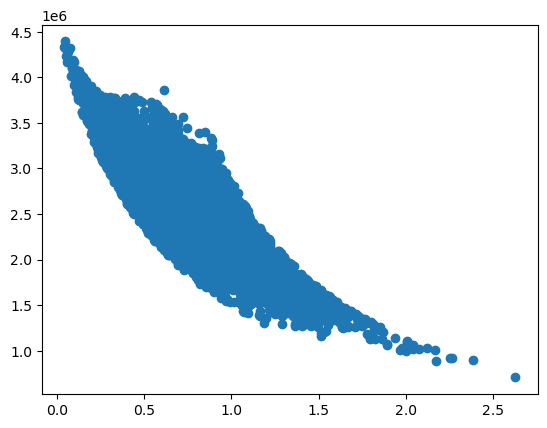

In [142]:
ran_ind = np.random.randint(0,gas_subhalo['count'], 4000)

plt.scatter(aux_dist[ran_ind], -gas_subhalo['Potential'][ran_ind])

In [127]:
G = 4.095 # km^2 Mpc / s^2 / Msun

In [132]:
gas_subhalo['count']

7470643

In [143]:
ran_ind = np.random.randint(0,gas_subhalo['count'], 400)
p1 = np.zeros(len(ran_ind))
p2 = np.zeros(len(ran_ind))
for j, jind in enumerate(ran_ind):
    p1[j] = gas_subhalo['Masses'][jind] * gas_subhalo['Potential'][jind]

    d1 = aux_dist[jind]
    mass_enclosed = np.sum(gas_subhalo['Masses'][np.where(aux_dist < d1)[0]])
    p2[j] = -G * mass_enclosed / d1

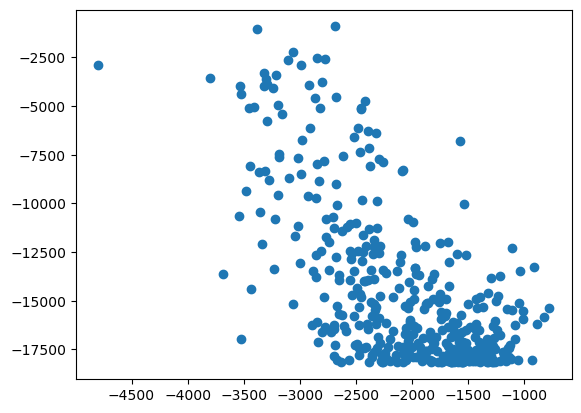

In [144]:
plt.scatter(p1,p2)

In [410]:
from scipy.interpolate import griddata

ran_ind = np.random.randint(0, gas_subhalo['count'], 10000)

# arrays 1D
x = gas_subhalo['Coordinates'][ran_ind,0]
y = gas_subhalo['Coordinates'][ran_ind,1]
z = energy[ran_ind]

# crear grilla regular
xi = np.linspace(x.min(), x.max(), 30)
yi = np.linspace(y.min(), y.max(), 30)

X, Y = np.meshgrid(xi, yi)

# interpolar z sobre la grilla
Z = griddata((x, y), z, (X, Y), method='linear')

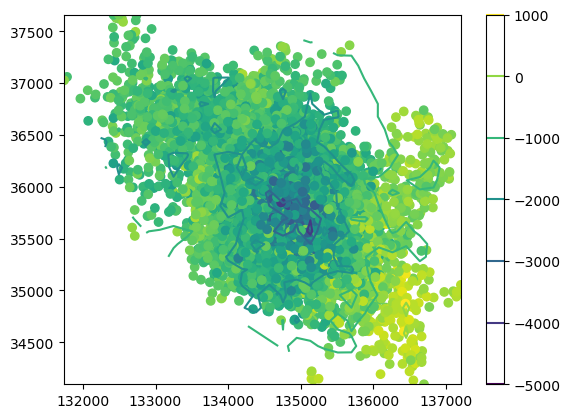

In [412]:
plt.scatter(gas_subhalo['Coordinates'][ran_ind,0], gas_subhalo['Coordinates'][ran_ind,1], c = energy[ran_ind])

# contour
plt.contour(X, Y, Z, levels=4)
plt.colorbar()

In [122]:
%%time
# Crear el archivo HDF5
with h5py.File('data_tree_halo3_2.hdf5', 'w') as hdf5_file:
    
    # Agrupar por halo_id_z0 para procesar cada halo una sola vez
    grouped_data = data.groupby('halo_id_z0')
    
    # Iterar sobre cada halo
    contador_halos = 0
    for halo_id_z0, halo_subhalos in tqdm(grouped_data, desc='Halos', total=len(grouped_data)):
        halo_id_z0 = int(halo_id_z0)
        print('Analizando Halo ' + str(halo_id_z0))
        if (contador_halos < 1) & (halo_id_z0 > 2):
            contador_halos += 1
            # Obtener el ID de la galaxia central (asumimos que es el mismo para todos los subhalos del halo)
            id_central_galaxy_z0 = int(halo_subhalos.iloc[0]['halo_id_central_galaxy_z0'])

            try:
                # Cargar evolución del halo
                halo_evolution = load_halo_evolution(myBasePath, halo_id_z0, id_central_galaxy_z0)

                if halo_evolution is None:
                    continue

                # Crear grupo para este halo
                halo_group = hdf5_file.create_group(f'halo_{halo_id_z0}')

                # Guardar datos del halo
                halo_group.create_dataset('pos_x', data=halo_evolution['pos_x'])
                halo_group.create_dataset('pos_y', data=halo_evolution['pos_y'])
                halo_group.create_dataset('pos_z', data=halo_evolution['pos_z'])
                halo_group.create_dataset('r200', data=halo_evolution['r200'])
                halo_group.create_dataset('m200', data=halo_evolution['m200'])
                halo_group.create_dataset('snapshots', data=halo_evolution['snapshots'])

                # Procesar cada subhalo de este halo
                contador_subhalos = 0
                for _, row in halo_subhalos[:].iterrows():
                    if (contador_subhalos < 10):
                        contador_subhalos += 1
                        sub_id_z0 = int(row['sub_id_z0'])

                        try:
                            # Cargar evolución del subhalo con correcciones de periodicidad
                            subhalo_evolution = load_subhalo_evolution(myBasePath, sub_id_z0, halo_evolution, plotear = False)

                            if subhalo_evolution is None:
                                continue

                            # Crear subgrupo para este subhalo dentro del halo
                            subhalo_group = halo_group.create_group(f'subhalo_{sub_id_z0}')

                            # Guardar datos del subhalo (ya corregidos por periodicidad)
                            subhalo_group.create_dataset('pos_x', data=subhalo_evolution['pos_x'])
                            subhalo_group.create_dataset('pos_y', data=subhalo_evolution['pos_y'])
                            subhalo_group.create_dataset('pos_z', data=subhalo_evolution['pos_z'])
                            subhalo_group.create_dataset('snapshots', data=subhalo_evolution['snapshots'])
                            subhalo_group.create_dataset('halfMassRad', data = subhalo_evolution['halfMassRad'])
                            subhalo_group.create_dataset('Subhalo_gas_mass', data = subhalo_evolution['Subhalo_gas_mass'])
                            subhalo_group.create_dataset('Subhalo_gas_num', data = subhalo_evolution['Subhalo_gas_num'])
                            subhalo_group.create_dataset('Subhalo_gas_T', data = subhalo_evolution['Subhalo_gas_T'])
                            subhalo_group.create_dataset('Halo_gas_mass', data = subhalo_evolution['Halo_gas_mass'])
                            subhalo_group.create_dataset('Halo_gas_num', data = subhalo_evolution['Halo_gas_num'])
                            subhalo_group.create_dataset('Halo_gas_T', data = subhalo_evolution['Halo_gas_T'])

                        except Exception as e:
                            continue

            except Exception as e:
                continue

Halos:   0%|          | 1/549 [00:00<01:49,  5.03it/s]

Analizando Halo 0
Analizando Halo 2
Analizando Halo 4
Snapshot 99. Subhalo 27878
Snapshot 89. Subhalo 27878
Snapshot 79. Subhalo 27878
Snapshot 69. Subhalo 27878
Snapshot 59. Subhalo 27878
Snapshot 49. Subhalo 27878
Snapshot 39. Subhalo 27878
Snapshot 29. Subhalo 27878
Snapshot 19. Subhalo 27878
Snapshot 9. Subhalo 27878
Snapshot 99. Subhalo 27879
Snapshot 89. Subhalo 27879
Snapshot 79. Subhalo 27879
Snapshot 69. Subhalo 27879
Snapshot 59. Subhalo 27879
Snapshot 49. Subhalo 27879
Snapshot 39. Subhalo 27879
Snapshot 29. Subhalo 27879
Snapshot 19. Subhalo 27879
Snapshot 9. Subhalo 27879
Snapshot 99. Subhalo 27880
Snapshot 89. Subhalo 27880
Snapshot 79. Subhalo 27880
Snapshot 69. Subhalo 27880
Snapshot 59. Subhalo 27880
Snapshot 49. Subhalo 27880
Snapshot 39. Subhalo 27880
Snapshot 29. Subhalo 27880
Snapshot 19. Subhalo 27880
Snapshot 9. Subhalo 27880
Snapshot 99. Subhalo 27881
Snapshot 89. Subhalo 27881
Snapshot 79. Subhalo 27881
Snapshot 69. Subhalo 27881
Snapshot 59. Subhalo 27881
Snap

Halos: 100%|██████████| 549/549 [58:58<00:00,  6.45s/it]    

Analizando Halo 6
Analizando Halo 7
Analizando Halo 8
Analizando Halo 9
Analizando Halo 10
Analizando Halo 12
Analizando Halo 14
Analizando Halo 15
Analizando Halo 16
Analizando Halo 17
Analizando Halo 19
Analizando Halo 20
Analizando Halo 21
Analizando Halo 22
Analizando Halo 23
Analizando Halo 24
Analizando Halo 25
Analizando Halo 26
Analizando Halo 28
Analizando Halo 29
Analizando Halo 30
Analizando Halo 32
Analizando Halo 33
Analizando Halo 37
Analizando Halo 38
Analizando Halo 39
Analizando Halo 40
Analizando Halo 41
Analizando Halo 42
Analizando Halo 43
Analizando Halo 45
Analizando Halo 46
Analizando Halo 47
Analizando Halo 48
Analizando Halo 49
Analizando Halo 50
Analizando Halo 53
Analizando Halo 54
Analizando Halo 55
Analizando Halo 56
Analizando Halo 57
Analizando Halo 59
Analizando Halo 60
Analizando Halo 61
Analizando Halo 62
Analizando Halo 65
Analizando Halo 66
Analizando Halo 67
Analizando Halo 68
Analizando Halo 70
Analizando Halo 71
Analizando Halo 72
Analizando Halo 

# PASO 5: ELIMINAR SUBHALOS SIN MERGER TREE

In [36]:
valid_sub_ids = []

with h5py.File('data_tree.hdf5', "r") as f:
    for halo_name in f.keys():
        halo_group = f[halo_name]

        # Buscar subhalos
        subhalos = [k for k in halo_group.keys() if k.startswith("subhalo_")]

        # Extraer el número de cada subhalo y guardarlo
        for sub_name in subhalos:
            sub_id = int(sub_name.split("_")[1])
            if sub_id == 1:
                print(halo_name)
            valid_sub_ids.append(sub_id)

# Convertimos a set para buscar rápido
valid_sub_ids = set(valid_sub_ids)

print(f"Total subhalos en merger tree: {len(valid_sub_ids)}")
print(f"Primeros 20 ids: {list(valid_sub_ids)[:20]}")

halo_30
Total subhalos en merger tree: 9735
Primeros 20 ids: [1, 2392066, 5, 6, 2457607, 7, 8, 1212426, 12, 1212428, 14, 2195472, 1114129, 1114130, 1114131, 1114132, 1114133, 20, 1114135, 2162705]


In [38]:
f = h5py.File('data_tree.hdf5', "r")

In [39]:
f['halo_30'].keys()

<KeysViewHDF5 ['m200', 'pos_x', 'pos_y', 'pos_z', 'r200', 'snapshots', 'subhalo_1', 'subhalo_1003', 'subhalo_101', 'subhalo_1019', 'subhalo_102', 'subhalo_1052', 'subhalo_1080', 'subhalo_109', 'subhalo_109278', 'subhalo_109279', 'subhalo_109280', 'subhalo_109281', 'subhalo_109282', 'subhalo_109283', 'subhalo_109284', 'subhalo_109285', 'subhalo_109286', 'subhalo_109287', 'subhalo_109288', 'subhalo_109289', 'subhalo_109290', 'subhalo_109291', 'subhalo_109292', 'subhalo_109293', 'subhalo_109294', 'subhalo_109295', 'subhalo_109296', 'subhalo_109297', 'subhalo_109298', 'subhalo_109299', 'subhalo_109300', 'subhalo_109301', 'subhalo_109302', 'subhalo_109303', 'subhalo_109304', 'subhalo_109305', 'subhalo_109306', 'subhalo_109307', 'subhalo_109308', 'subhalo_109309', 'subhalo_109310', 'subhalo_109311', 'subhalo_109312', 'subhalo_109313', 'subhalo_109314', 'subhalo_109315', 'subhalo_109316', 'subhalo_109317', 'subhalo_109318', 'subhalo_109319', 'subhalo_109320', 'subhalo_109321', 'subhalo_109322

In [42]:
data[data['halo_id_z0'] == 0]

,halo_id_z0,sub_id_z0,sub_mstar_z0,sub_pos_x_z0,sub_pos_y_z0,sub_pos_z_z0,sub_vel_x_z0,sub_vel_y_z0,sub_vel_z_z0,sub_dist_3d_z0,halo_id_central_galaxy_z0,halo_r200_z0,halo_m200_z0,halo_pos_x_z0,halo_pos_y_z0,halo_pos_z_z0,halo_vel_x_z0,halo_vel_y_z0,halo_vel_z_z0
0,0.0,0,12.725053,43.718811,48.813641,147.594955,472.196198,450.850006,-260.746918,0.000000,0.0,1.647926,15.017178,43.718811,48.813641,147.594955,296.780029,122.684685,-89.75425
1,0.0,1,12.404258,45.442272,51.850201,146.416504,-209.056656,-735.888916,400.641724,3.685073,0.0,1.647926,15.017178,43.718811,48.813641,147.594955,296.780029,122.684685,-89.75425
2,0.0,2,11.758653,44.490761,49.091713,147.870575,2021.729492,1495.440186,-1797.082153,0.865562,0.0,1.647926,15.017178,43.718811,48.813641,147.594955,296.780029,122.684685,-89.75425
3,0.0,3,11.378576,43.820786,50.939400,147.711044,925.150391,-473.445465,-275.925934,2.131367,0.0,1.647926,15.017178,43.718811,48.813641,147.594955,296.780029,122.684685,-89.75425
4,0.0,4,11.343598,44.302578,49.630974,147.869492,-260.214630,-2221.625244,-563.641296,1.041243,0.0,1.647926,15.017178,43.718811,48.813641,147.594955,296.780029,122.684685,-89.75425
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1083,0.0,3216995,9.129765,43.852852,48.255424,150.983536,414.792206,843.950562,-411.751404,3.436866,0.0,1.647926,15.017178,43.718811,48.813641,147.594955,296.780029,122.684685,-89.75425
1084,0.0,3254912,9.660554,47.069798,52.358681,144.897247,-331.305695,-342.648254,802.927063,5.574410,0.0,1.647926,15.017178,43.718811,48.813641,147.594955,296.780029,122.684685,-89.75425
1085,0.0,3365177,9.257822,43.944557,49.532253,149.814545,511.098175,746.738220,-1090.504028,2.343916,0.0,1.647926,15.017178,43.718811,48.813641,147.594955,296.780029,122.684685,-89.75425
1086,0.0,3459051,9.090504,45.370193,53.304314,144.906036,-41.093105,-1332.411743,468.574585,5.488488,0.0,1.647926,15.017178,43.718811,48.813641,147.594955,296.780029,122.684685,-89.75425


In [43]:
data[data['halo_id_z0'] == 30]

,halo_id_z0,sub_id_z0,sub_mstar_z0,sub_pos_x_z0,sub_pos_y_z0,sub_pos_z_z0,sub_vel_x_z0,sub_vel_y_z0,sub_vel_z_z0,sub_dist_3d_z0,halo_id_central_galaxy_z0,halo_r200_z0,halo_m200_z0,halo_pos_x_z0,halo_pos_y_z0,halo_pos_z_z0,halo_vel_x_z0,halo_vel_y_z0,halo_vel_z_z0
7306,30.0,1,12.404258,45.442272,51.850201,146.416504,-209.056656,-735.888916,400.641724,5.036208,109278.0,1.042946,14.421161,46.616356,55.904087,143.66861,-843.413879,-686.598877,709.510193
7307,30.0,5,10.960866,44.014526,52.243404,144.518005,232.693069,-1474.725464,975.914124,4.570732,109278.0,1.042946,14.421161,46.616356,55.904087,143.66861,-843.413879,-686.598877,709.510193
7308,30.0,6,11.270103,45.629852,52.255409,146.021912,-536.066345,254.314072,1566.847046,4.452423,109278.0,1.042946,14.421161,46.616356,55.904087,143.66861,-843.413879,-686.598877,709.510193
7309,30.0,7,11.020243,46.637634,53.009380,146.825516,444.622681,332.752960,-250.658142,4.283204,109278.0,1.042946,14.421161,46.616356,55.904087,143.66861,-843.413879,-686.598877,709.510193
7310,30.0,8,10.793513,44.246441,52.066494,145.527481,-949.234985,-1813.723511,-986.660706,4.878424,109278.0,1.042946,14.421161,46.616356,55.904087,143.66861,-843.413879,-686.598877,709.510193
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7759,30.0,3047253,9.464477,47.341583,52.545105,144.916977,-237.793076,-316.070465,654.842224,3.656110,109278.0,1.042946,14.421161,46.616356,55.904087,143.66861,-843.413879,-686.598877,709.510193
7760,30.0,3209671,9.268044,46.040581,51.454102,144.398880,-127.356316,-614.163208,406.900238,4.546117,109278.0,1.042946,14.421161,46.616356,55.904087,143.66861,-843.413879,-686.598877,709.510193
7761,30.0,3254912,9.660554,47.069798,52.358681,144.897247,-331.305695,-342.648254,802.927063,3.779559,109278.0,1.042946,14.421161,46.616356,55.904087,143.66861,-843.413879,-686.598877,709.510193
7762,30.0,3459051,9.090504,45.370193,53.304314,144.906036,-41.093105,-1332.411743,468.574585,3.137351,109278.0,1.042946,14.421161,46.616356,55.904087,143.66861,-843.413879,-686.598877,709.510193


In [28]:
valid_sub_ids

{1,
 2392066,
 5,
 6,
 2457607,
 7,
 8,
 1212426,
 12,
 1212428,
 14,
 2195472,
 1114129,
 1114130,
 1114131,
 1114132,
 1114133,
 20,
 1114135,
 2162705,
 2424849,
 1114138,
 1114139,
 3145754,
 29,
 30,
 31,
 2097180,
 33,
 34,
 786459,
 786460,
 786461,
 786462,
 786463,
 786464,
 786465,
 786466,
 44,
 45,
 786476,
 49,
 2326579,
 2064438,
 2064439,
 56,
 71,
 75,
 76,
 78,
 79,
 80,
 82,
 86,
 93,
 94,
 2293853,
 101,
 102,
 109,
 111,
 115,
 121,
 132,
 135,
 142,
 143,
 147,
 149,
 150,
 152,
 2293915,
 1999004,
 1999005,
 160,
 161,
 1671330,
 165,
 168,
 170,
 172,
 1999022,
 2293934,
 183,
 192,
 194,
 198,
 200,
 202,
 205,
 206,
 1966296,
 217,
 219,
 221,
 223,
 225,
 231,
 2949353,
 238,
 240,
 242,
 2168843,
 251,
 2130172,
 253,
 1442046,
 1442047,
 1442048,
 1442049,
 264,
 267,
 2261260,
 270,
 274,
 2359570,
 277,
 278,
 283,
 285,
 290,
 2228525,
 302,
 304,
 305,
 312,
 313,
 316,
 2195774,
 320,
 339,
 346,
 350,
 2097502,
 352,
 355,
 360,
 361,
 362,
 369,
 372,

In [23]:
data_clean = data[data["sub_id_z0"].isin(valid_sub_ids)].copy()

print(f"Subhalos originales en DataFrame: {len(data)}")
print(f"Subhalos después de limpieza: {len(data_clean)}")

Subhalos originales en DataFrame: 39132
Subhalos después de limpieza: 10294


In [24]:
# Eliminamos duplicados
data_clean_final = data_clean.drop_duplicates(subset=['sub_id_z0'])
print(len(data_clean_final))

9735


In [44]:
data_clean_final.to_csv('link_halo_subhalos_z0.dat', sep=' ', index=False)

In [45]:
data_clean_final

,halo_id_z0,sub_id_z0,sub_mstar_z0,sub_pos_x_z0,sub_pos_y_z0,sub_pos_z_z0,sub_vel_x_z0,sub_vel_y_z0,sub_vel_z_z0,sub_dist_3d_z0,halo_id_central_galaxy_z0,halo_r200_z0,halo_m200_z0,halo_pos_x_z0,halo_pos_y_z0,halo_pos_z_z0,halo_vel_x_z0,halo_vel_y_z0,halo_vel_z_z0
1,0.0,1,12.404258,45.442272,51.850201,146.416504,-209.056656,-735.888916,400.641724,3.685073,0.0,1.647926,15.017178,43.718811,48.813641,147.594955,296.780029,122.684685,-89.75425
5,0.0,5,10.960866,44.014526,52.243404,144.518005,232.693069,-1474.725464,975.914124,4.617180,0.0,1.647926,15.017178,43.718811,48.813641,147.594955,296.780029,122.684685,-89.75425
6,0.0,6,11.270103,45.629852,52.255409,146.021912,-536.066345,254.314072,1566.847046,4.239377,0.0,1.647926,15.017178,43.718811,48.813641,147.594955,296.780029,122.684685,-89.75425
7,0.0,7,11.020243,46.637634,53.009380,146.825516,444.622681,332.752960,-250.658142,5.168733,0.0,1.647926,15.017178,43.718811,48.813641,147.594955,296.780029,122.684685,-89.75425
8,0.0,8,10.793513,44.246441,52.066494,145.527481,-949.234985,-1813.723511,-986.660706,3.890231,0.0,1.647926,15.017178,43.718811,48.813641,147.594955,296.780029,122.684685,-89.75425
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
12265,67.0,2358768,9.537780,151.195938,179.660110,88.639824,-422.387726,-290.944977,-574.038879,2.677402,180645.0,0.933181,14.276215,149.258194,179.401138,86.810463,31.700628,5.820291,-205.57962
12266,67.0,2363675,9.265315,147.474518,179.700760,84.670616,692.805420,-198.002716,-145.534637,2.801824,180645.0,0.933181,14.276215,149.258194,179.401138,86.810463,31.700628,5.820291,-205.57962
12267,67.0,2396918,10.033054,148.463394,179.835831,88.251274,148.350479,-192.487549,-43.660084,1.701940,180645.0,0.933181,14.276215,149.258194,179.401138,86.810463,31.700628,5.820291,-205.57962
12268,67.0,2479605,9.146558,149.731522,180.744186,87.139709,76.791817,-222.259674,-285.191162,1.461581,180645.0,0.933181,14.276215,149.258194,179.401138,86.810463,31.700628,5.820291,-205.57962


In [46]:
data_clean

,halo_id_z0,sub_id_z0,sub_mstar_z0,sub_pos_x_z0,sub_pos_y_z0,sub_pos_z_z0,sub_vel_x_z0,sub_vel_y_z0,sub_vel_z_z0,sub_dist_3d_z0,halo_id_central_galaxy_z0,halo_r200_z0,halo_m200_z0,halo_pos_x_z0,halo_pos_y_z0,halo_pos_z_z0,halo_vel_x_z0,halo_vel_y_z0,halo_vel_z_z0
1,0.0,1,12.404258,45.442272,51.850201,146.416504,-209.056656,-735.888916,400.641724,3.685073,0.0,1.647926,15.017178,43.718811,48.813641,147.594955,296.780029,122.684685,-89.754250
5,0.0,5,10.960866,44.014526,52.243404,144.518005,232.693069,-1474.725464,975.914124,4.617180,0.0,1.647926,15.017178,43.718811,48.813641,147.594955,296.780029,122.684685,-89.754250
6,0.0,6,11.270103,45.629852,52.255409,146.021912,-536.066345,254.314072,1566.847046,4.239377,0.0,1.647926,15.017178,43.718811,48.813641,147.594955,296.780029,122.684685,-89.754250
7,0.0,7,11.020243,46.637634,53.009380,146.825516,444.622681,332.752960,-250.658142,5.168733,0.0,1.647926,15.017178,43.718811,48.813641,147.594955,296.780029,122.684685,-89.754250
8,0.0,8,10.793513,44.246441,52.066494,145.527481,-949.234985,-1813.723511,-986.660706,3.890231,0.0,1.647926,15.017178,43.718811,48.813641,147.594955,296.780029,122.684685,-89.754250
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
37252,696.0,2129827,9.584888,68.367905,41.028316,154.934402,-127.097618,854.625305,502.057648,1.638946,598719.0,0.543383,13.571643,67.038170,41.896214,155.340240,-113.696388,384.117493,168.158234
37253,696.0,2178275,9.905128,67.319359,43.729145,156.124817,14.604185,-409.517212,-33.056145,2.013521,598719.0,0.543383,13.571643,67.038170,41.896214,155.340240,-113.696388,384.117493,168.158234
37255,696.0,2255085,9.729881,68.120117,41.857384,154.668182,-543.803101,460.068481,327.201355,1.274276,598719.0,0.543383,13.571643,67.038170,41.896214,155.340240,-113.696388,384.117493,168.158234
37256,696.0,2255784,9.283740,68.393616,41.524864,155.331528,-232.227951,936.474548,476.195007,1.405422,598719.0,0.543383,13.571643,67.038170,41.896214,155.340240,-113.696388,384.117493,168.158234
